# Selecting EnKF covariance inflation with proper scoring rules

This deep dive combines two earlier examples:

- [Filtering of deterministic continuous-time processes](filtering_deterministic_processes.ipynb), which uses a partially observed Lorenz–63 system, and
- [Part 12: Observation scoring for filter predictive distributions](../tutorials/gentle_intro/12_observation_scoring_with_filters.ipynb), which introduces proper scoring rules.

Here the latent process is a Lorenz–63 **SDE** with a small diffusion scale of $1e-4$, and inference uses the continuous-time **CD-Dynamax EnKF**. We treat covariance inflation $\delta$ as a tuning parameter and select it in two ways:

1. evaluate a grid in parallel with `jax.vmap`, then plot each scoring-rule profile;
2. refine the Gaussian log-score optimum with autodiff L-BFGS.

The EnKF seed and score-sampling seed are fixed throughout. These common random numbers make differences across inflation settings reflect the parameter rather than fresh Monte Carlo noise.

## What is being optimized?

At each observation time, the filter produces the one-step-ahead distribution

$$p(y_t\mid y_{1:t-1};\delta).$$

Inflation expands the ensemble anomalies before assimilation,

$$x_t^{(i)}-\bar x_t \longmapsto (1+\delta)\left(x_t^{(i)}-\bar x_t\right),$$

which can prevent collapse but can also make the filter unnecessarily diffuse. Proper scores balance calibration and sharpness. We compare:

- Gaussian log probability (higher is better),
- Dawid–Sebastiani score (lower is better),
- observation-wise Gaussian CRPS (lower is better), and
- energy scores with $\beta=1$ and $\beta=1.5$ (lower is better).

The target below is the temporal mean score on one held-out trajectory. For a production tuning workflow, average scores over multiple validation trajectories or rolling forecast origins.

In [12]:
import os
import warnings
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from IPython.display import Markdown, display
from jaxopt import LBFGS
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Evaluation,
    Filter,
    LinearGaussianObservation,
    ScalarDiffusion,
    SDESimulator,
    SDESimulatorConfig,
)
from dynestyx.evaluation.configs import ObservationScoringConfig
from dynestyx.evaluation.scoring import (
    DawidSebastianiScore,
    EnergyScore,
    GaussianLogProbScore,
    ObservationWiseCRPSScore,
)
from dynestyx.inference.configs.filter import ContinuousTimeEnKFConfig

warnings.filterwarnings("ignore", message="A JAX array is being set as static!")

STATE_DIM = 3
TRUE_RHO = 28.0
DIFFUSION_SCALE = 0.0001
OBS_DT = 0.05
OBS_BURN_IN_TIME = 100.0
OBS_FINAL_TIME = 15.0
ANALYSIS_FINAL_TIME = 8.0
FILTER_DT0 = 0.005
N_ENSEMBLE = 30
FULL_SIM_TIMES = jnp.arange(
    0.0, OBS_BURN_IN_TIME + OBS_FINAL_TIME + 1e-9, OBS_DT
)

TRUTH_COLOR = "#222222"
OBS_COLOR = "#666666"
PROFILE_COLOR = "#2171B5"
OPTIMIZER_COLOR = "#D55E00"

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

default_figure_dir = (
    Path("docs/deep_dives/figures/l63_covariance_inflation_scoring")
    if Path("docs").exists()
    else Path("figures/l63_covariance_inflation_scoring")
)
FIGURE_DIR = Path(os.environ.get("DYNESTYX_FIGURE_DIR", default_figure_dir))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.pdf")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300)


## Lorenz–63 SDE and data

We retain the initial-condition and observation design of the deterministic-process notebook,

$$X_0\sim\mathcal N(0,20^2I_3),\qquad Y_k=[1\;0\;0]X_{t_k}+\varepsilon_k,\qquad \varepsilon_k\sim\mathcal N(0,1),$$

but add isotropic process diffusion $0.0001I_3$. As before, we discard a burn-in of 100 time units and use observations through $t=8$ for the comparison.

In [13]:
def l63_dynamics(rho=TRUE_RHO):
    def drift(x, u, t):
        return jnp.array([
            10.0 * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - (8.0 / 3.0) * x[2],
        ])

    return DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(STATE_DIM),
            covariance_matrix=20.0**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=drift,
            diffusion=ScalarDiffusion(DIFFUSION_SCALE, bm_dim=STATE_DIM),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )


def l63_model(obs_times=None, obs_values=None, predict_times=None, rho=TRUE_RHO):
    return dsx.sample(
        "f",
        l63_dynamics(rho),
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def simulate_dataset(*, key=jr.PRNGKey(0)):
    predictive = Predictive(
        l63_model,
        num_samples=1,
        exclude_deterministic=False,
    )
    with SDESimulator(simulator_config=SDESimulatorConfig(source="em_scan")):
        synthetic = predictive(key, rho=TRUE_RHO, predict_times=FULL_SIM_TIMES)

    full_times = synthetic["f_times"][0, 0]
    full_states = synthetic["f_states"][0, 0]
    full_observations = synthetic["f_observations"][0, 0]
    keep = full_times >= OBS_BURN_IN_TIME - 1e-12
    return {
        "times": full_times[keep] - OBS_BURN_IN_TIME,
        "states": full_states[keep],
        "observations": full_observations[keep],
    }


retained observations: 301
observations used for tuning: 161
process diffusion scale: 0.0001


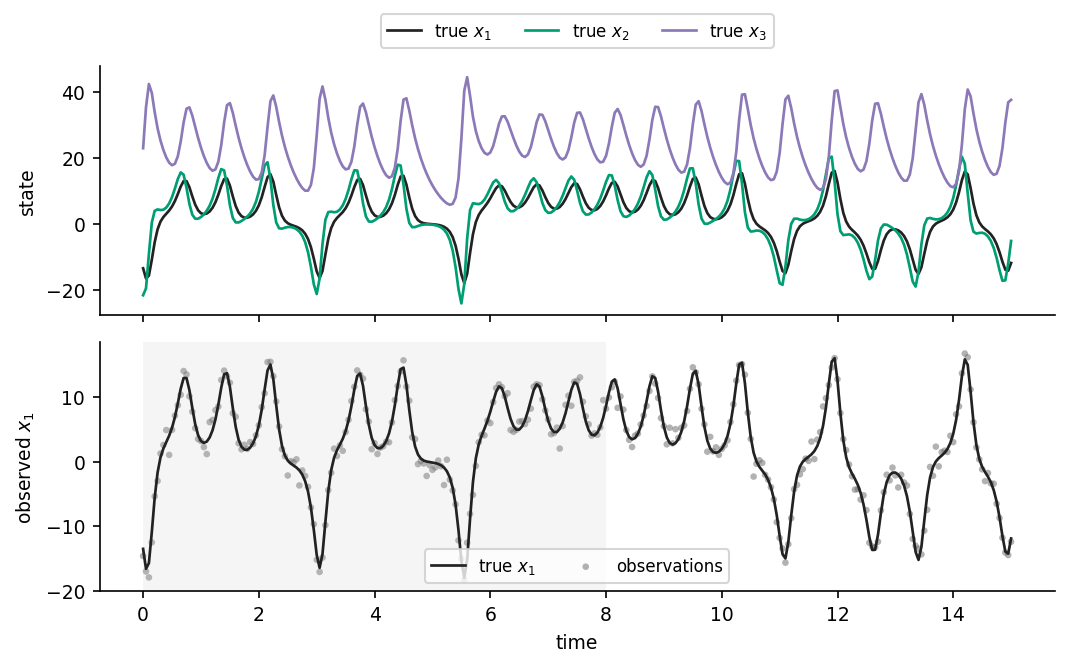

In [14]:
dataset = simulate_dataset()
analysis_mask = dataset["times"] <= ANALYSIS_FINAL_TIME + 1e-12
obs_times = dataset["times"][analysis_mask]
obs_values = dataset["observations"][analysis_mask]
true_states = dataset["states"][analysis_mask]

print(f"retained observations: {dataset['observations'].shape[0]}")
print(f"observations used for tuning: {obs_values.shape[0]}")
print(f"process diffusion scale: {DIFFUSION_SCALE}")

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.5), sharex=True)
for state_index, color in enumerate(("#222222", "#009E73", "#8C79B8")):
    axes[0].plot(
        dataset["times"],
        dataset["states"][:, state_index],
        color=color,
        linewidth=1.3,
        label=fr"true $x_{state_index + 1}$",
    )
axes[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.24))
axes[0].set_ylabel("state")

axes[1].plot(
    dataset["times"], dataset["states"][:, 0],
    color=TRUTH_COLOR, linewidth=1.3, label=r"true $x_1$",
)
axes[1].scatter(
    dataset["times"], dataset["observations"][:, 0],
    s=10, color=OBS_COLOR, alpha=0.5, edgecolors="none", label="observations",
)
axes[1].axvspan(0.0, ANALYSIS_FINAL_TIME, color="#BDBDBD", alpha=0.15, linewidth=0)
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"observed $x_1$")
axes[1].legend(ncol=2)
fig.tight_layout()
save_figure(fig, "l63_sde_data")
plt.show()


## Score one inflation setting

`Evaluation` sits outside the CD-Dynamax `Filter`, so it receives the EnKF's one-step predictive observation summaries. The filter and score-sampling seeds are fixed. We retain each per-time score until the final temporal average.

In [15]:
METRIC_SPECS = (
    ("gaussian_log_prob", "Gaussian log-prob", "higher"),
    ("dawid_sebastiani", "Dawid–Sebastiani", "lower"),
    ("observation_wise_crps", "Observation-wise CRPS", "lower"),
    ("energy_score", r"Energy score ($\beta=1$)", "lower"),
    ("energy_score_beta_1_5", r"Energy score ($\beta=1.5$)", "lower"),
)

scoring_config = ObservationScoringConfig(
    rules=(
        GaussianLogProbScore(),
        DawidSebastianiScore(),
        ObservationWiseCRPSScore(),
        EnergyScore(beta=1.0, n_samples=128),
        EnergyScore(beta=1.5, n_samples=128),
    ),
    sample_source="auto",
    sample_seed=17,
    record_as_numpyro_sites=False,
)


def make_enkf_config(inflation_delta, *, include_predictions=True):
    return ContinuousTimeEnKFConfig(
        n_particles=N_ENSEMBLE,
        crn_seed=jr.PRNGKey(31415),
        inflation_delta=inflation_delta,
        diffeqsolve_dt0=FILTER_DT0,
        include_predicted_observations=include_predictions,
        record_filtered_states_mean=False,
        record_filtered_states_cov=False,
        record_filtered_states_cov_diag=False,
        record_filtered_states_chol_cov=False,
        record_predicted_observations_mean=False,
        record_predicted_observations_cov=False,
        record_predicted_observations_ensemble=False,
        warn=False,
    )


def mean_score_vector(inflation_delta):
    filter_config = make_enkf_config(inflation_delta)
    with Evaluation(observation_scoring_config=scoring_config):
        with Filter(filter_config=filter_config):
            result = dsx.condition(
                "f",
                l63_dynamics(),
                obs_times=obs_times,
                obs_values=obs_values,
            )
    score_arrays = result.evaluation_result.observation_scores
    return jnp.stack([
        jnp.mean(score_arrays[site_name])
        for site_name, _, _ in METRIC_SPECS
    ])


example_scores = mean_score_vector(0.10)
for (_, label, objective), value in zip(METRIC_SPECS, example_scores, strict=True):
    print(f"{label:28s}: {float(value): .5f}  ({objective} is better)")


Gaussian log-prob           : -1.68591  (higher is better)
Dawid–Sebastiani            :  1.53394  (lower is better)
Observation-wise CRPS       :  0.78727  (lower is better)
Energy score ($\beta=1$)    :  0.80331  (lower is better)
Energy score ($\beta=1.5$)  :  1.43676  (lower is better)


## Vectorized grid search

CD-Dynamax 0.4.1 accepts a traced `inflation_delta`, so the grid calculation is simply `jax.vmap(mean_score_vector)(INFLATION_GRID)`. Each row of the resulting array corresponds to one inflation value, and each column to one scoring rule.

In [16]:
# log-spaced 0 to 1.0 with 100 points
INFLATION_GRID = np.linspace(0.0, 0.5, 30)

grid_scores = np.asarray(jax.vmap(mean_score_vector)(INFLATION_GRID))
print("grid score array shape:", grid_scores.shape)


grid score array shape: (30, 5)


| Scoring rule | Direction | Best grid inflation | Mean score |
|---|:---:|---:|---:|
| Gaussian log-prob | higher | 0.017 | -1.62277 |
| Dawid–Sebastiani | lower | 0.017 | 1.40765 |
| Observation-wise CRPS | lower | 0.017 | 0.74345 |
| Energy score ($\beta=1$) | lower | 0.000 | 0.75708 |
| Energy score ($\beta=1.5$) | lower | 0.000 | 1.33900 |

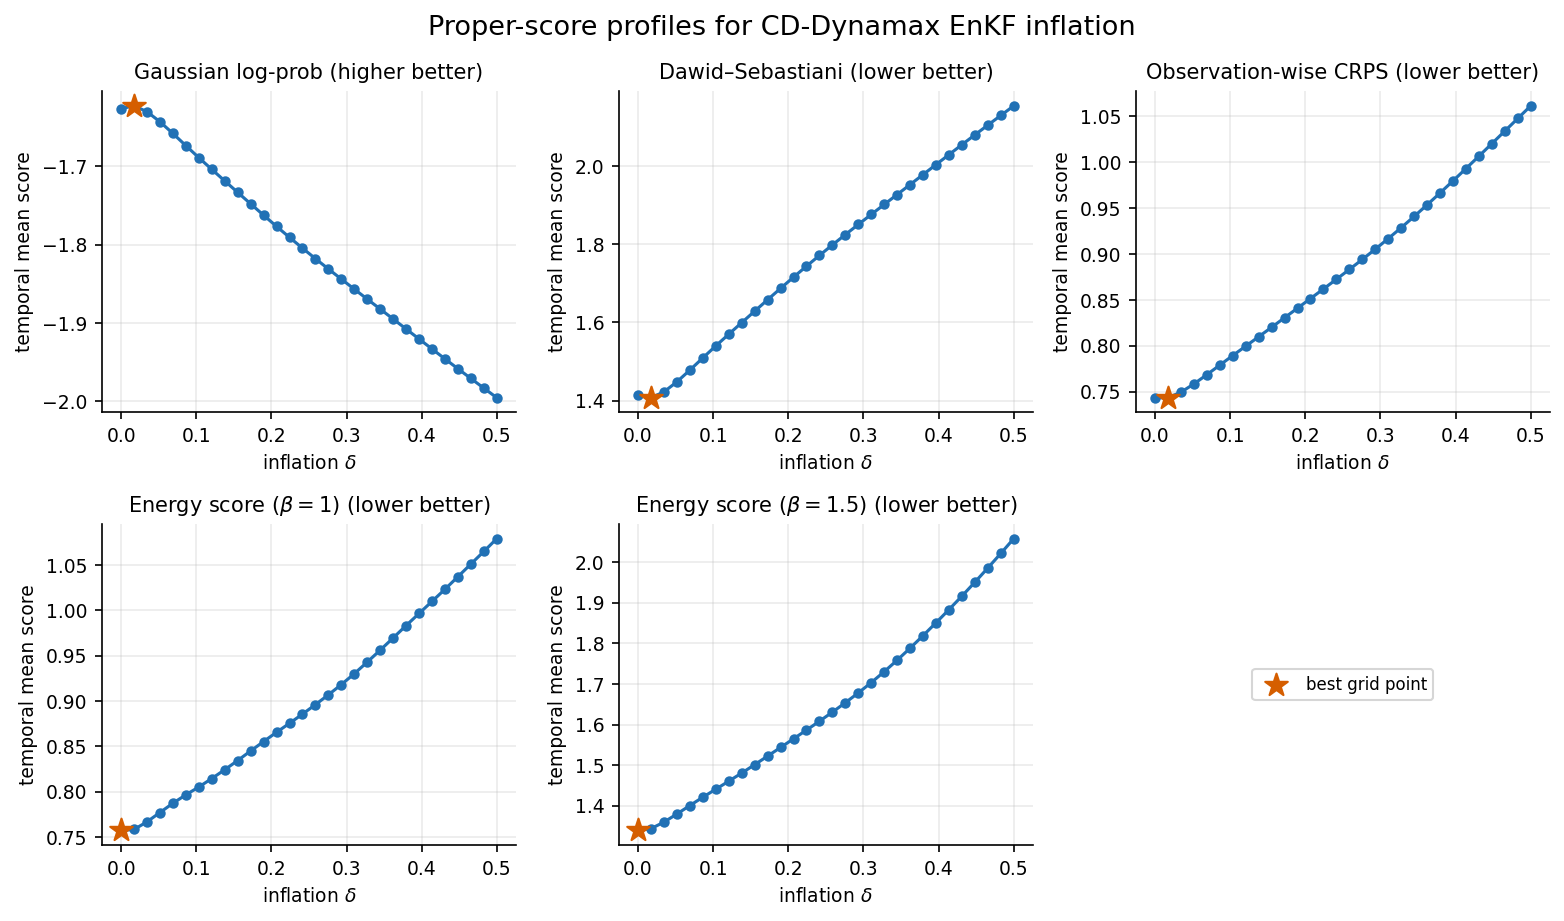

In [17]:
grid_optima = []
table_lines = [
    "| Scoring rule | Direction | Best grid inflation | Mean score |",
    "|---|:---:|---:|---:|",
]
for metric_index, (_, label, objective) in enumerate(METRIC_SPECS):
    values = grid_scores[:, metric_index]
    best_index = int(np.argmax(values) if objective == "higher" else np.argmin(values))
    best_delta = float(INFLATION_GRID[best_index])
    grid_optima.append(best_delta)
    table_lines.append(
        f"| {label} | {objective} | {best_delta:.3f} | {values[best_index]:.5f} |"
    )

display(Markdown("\n".join(table_lines)))

fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.2))
axes = axes.ravel()
for metric_index, (ax, (_, label, objective)) in enumerate(
    zip(axes[:-1], METRIC_SPECS, strict=True)
):
    values = grid_scores[:, metric_index]
    best_index = int(np.argmax(values) if objective == "higher" else np.argmin(values))
    ax.plot(INFLATION_GRID, values, color=PROFILE_COLOR, marker="o", markersize=4)
    ax.scatter(
        INFLATION_GRID[best_index], values[best_index],
        marker="*", s=130, color=OPTIMIZER_COLOR, zorder=3, label="best grid point",
    )
    ax.set_title(f"{label} ({objective} better)")
    ax.set_xlabel(r"inflation $\delta$")
    ax.set_ylabel("temporal mean score")
    ax.grid(alpha=0.25)

axes[-1].axis("off")
axes[-1].legend(*axes[0].get_legend_handles_labels(), loc="center")
fig.suptitle("Proper-score profiles for CD-Dynamax EnKF inflation", fontsize=13)
fig.tight_layout()
save_figure(fig, "inflation_score_profiles")
plt.show()


## Refine the optimum with autodiff L-BFGS

We now optimize the negative Gaussian log score with `jaxopt.LBFGS`. A sigmoid maps an unconstrained scalar $z$ into the profiled interval,

$$\delta(z)=0.3\,\mathrm{sigmoid}(z).$$

This is reverse-mode autodiff through the complete CD-Dynamax EnKF and its SDE solves. We use a scoring configuration containing only the Gaussian log score: sample-based energy scores contain non-smooth pairwise norms and are better treated with the grid profile.

In [18]:
GAUSSIAN_LOG_SCORE_INDEX = 0
MAX_INFLATION = 1.00

gaussian_scoring_config = ObservationScoringConfig(
    rules=(GaussianLogProbScore(),),
    record_as_numpyro_sites=False,
)


def mean_gaussian_log_score(inflation_delta):
    filter_config = make_enkf_config(inflation_delta)
    with Evaluation(observation_scoring_config=gaussian_scoring_config):
        with Filter(filter_config=filter_config):
            result = dsx.condition(
                "f",
                l63_dynamics(),
                obs_times=obs_times,
                obs_values=obs_values,
            )
    return jnp.mean(
        result.evaluation_result.observation_scores["gaussian_log_prob"]
    )


def bounded_inflation(unconstrained):
    return MAX_INFLATION * jax.nn.sigmoid(unconstrained)


def objective(unconstrained):
    return -mean_gaussian_log_score(bounded_inflation(unconstrained))


initial_delta = 0.1
initial_unconstrained = jnp.log(initial_delta / (MAX_INFLATION - initial_delta))
initial_loss, initial_gradient = jax.value_and_grad(objective)(
    initial_unconstrained
)

solver = LBFGS(
    fun=objective,
    maxiter=30,
    tol=1e-6,
    history_size=8,
    implicit_diff=False,
)
optimizer_result = solver.run(initial_unconstrained)

optimized_delta = float(bounded_inflation(optimizer_result.params))
optimized_log_score = -float(optimizer_result.state.value)
grid_start = grid_optima[GAUSSIAN_LOG_SCORE_INDEX]

print(f"initial delta       : {initial_delta:.5f}")
print(f"autodiff gradient   : {float(initial_gradient): .6f}")
print(f"grid optimum        : delta={grid_start:.5f}")
print(f"L-BFGS optimum      : delta={optimized_delta:.5f}")
print(f"mean log score      : {optimized_log_score:.6f}")
print(f"iterations          : {int(optimizer_result.state.iter_num)}")
print(f"final gradient error: {float(optimizer_result.state.error):.3e}")


initial delta       : 0.10000
autodiff gradient   :  0.079449
grid optimum        : delta=0.01724
L-BFGS optimum      : delta=0.01282
mean log score      : -1.622366
iterations          : 8
final gradient error: 1.449e-07


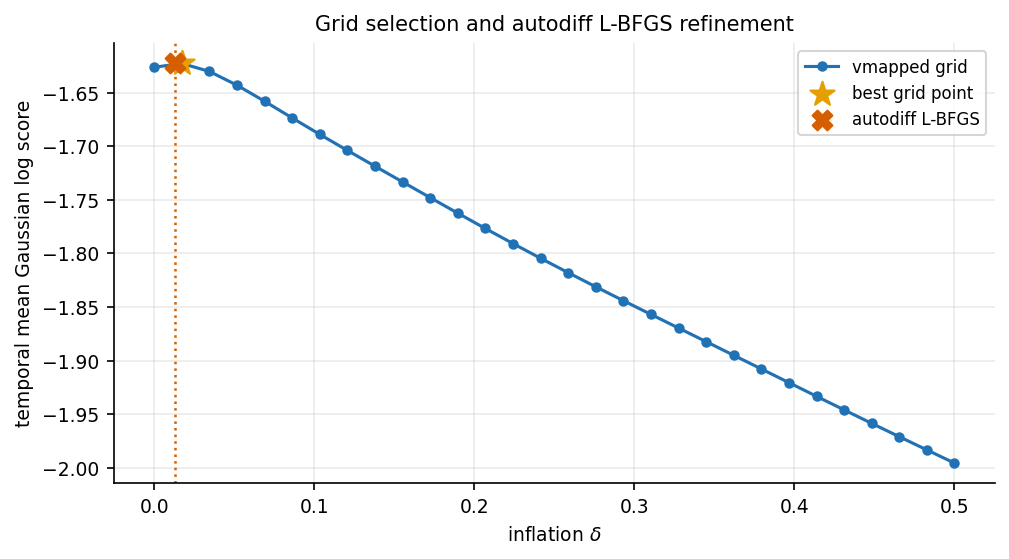

In [19]:
log_score_grid = grid_scores[:, GAUSSIAN_LOG_SCORE_INDEX]
grid_best_index = int(np.argmax(log_score_grid))

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(
    INFLATION_GRID, log_score_grid,
    color=PROFILE_COLOR, marker="o", markersize=4, label="vmapped grid",
)
ax.scatter(
    INFLATION_GRID[grid_best_index], log_score_grid[grid_best_index],
    marker="*", s=150, color="#E69F00", zorder=3, label="best grid point",
)
ax.scatter(
    optimized_delta, optimized_log_score,
    marker="X", s=90, color=OPTIMIZER_COLOR, zorder=4, label="autodiff L-BFGS",
)
ax.axvline(optimized_delta, color=OPTIMIZER_COLOR, linestyle=":", linewidth=1.2)
ax.set_xlabel(r"inflation $\delta$")
ax.set_ylabel("temporal mean Gaussian log score")
ax.set_title("Grid selection and autodiff L-BFGS refinement")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "lbfgs_refinement")
plt.show()


## Takeaways

- Proper scores turn covariance inflation into an observable predictive-performance tuning problem.
- Different proper scores need not select exactly the same $\delta$: they emphasize distributional quality differently.
- Fixing the EnKF and score-sampling seeds provides common random numbers and a stable comparison across the grid.
- CD-Dynamax 0.4.1 accepts traced inflation values directly, so `vmap` and reverse-mode autodiff work through the public EnKF path without a compatibility shim.
- The grid is still valuable even when an optimizer is available: EnKF score profiles can be non-convex, and L-BFGS is a local method.
- For scientific tuning, repeat the calculation across validation trajectories and average the per-trajectory scores before selecting inflation.

## State recovery at the selected inflation

Finally, we compare filtering with the optimized inflation against the naïve choice $\delta=0.10$ used in the deterministic-process example. Both runs use the same 30-member ensemble, common-random-number seed, model parameters, and observations; only inflation changes.

The bands below are Gaussian 90% marginal intervals from the filtered EnKF moments. Because filtering is causal, every estimate at time $t$ uses observations only through time $t$.

In [20]:
NAIVE_INFLATION = 0.5


def run_state_recovery(inflation_delta):
    filter_config = make_enkf_config(
        inflation_delta, include_predictions=False
    )
    with Filter(filter_config=filter_config):
        result = dsx.condition(
            "f",
            l63_dynamics(),
            obs_times=obs_times,
            obs_values=obs_values,
        )

    mean = np.asarray(result.states.filtered_means)
    covariance = np.asarray(result.states.filtered_covariances)
    std = np.sqrt(np.maximum(np.diagonal(covariance, axis1=-2, axis2=-1), 0.0))
    return {
        "mean": mean,
        "lo90": mean - 1.64485 * std,
        "hi90": mean + 1.64485 * std,
    }


recovery_results = {
    fr"optimized $\delta={optimized_delta:.4f}$": run_state_recovery(
        optimized_delta
    ),
    fr"naïve $\delta={NAIVE_INFLATION:.2f}$": run_state_recovery(
        NAIVE_INFLATION
    ),
}


| Inflation choice | Overall RMSE | State RMSE $(x_1,x_2,x_3)$ | 90% coverage |
|---|---:|:---:|---:|
| optimized $\delta=0.0128$ | 1.647 | 0.521, 2.158, 1.793 | 0.783 |
| naïve $\delta=0.50$ | 2.550 | 0.906, 2.766, 3.322 | 0.932 |

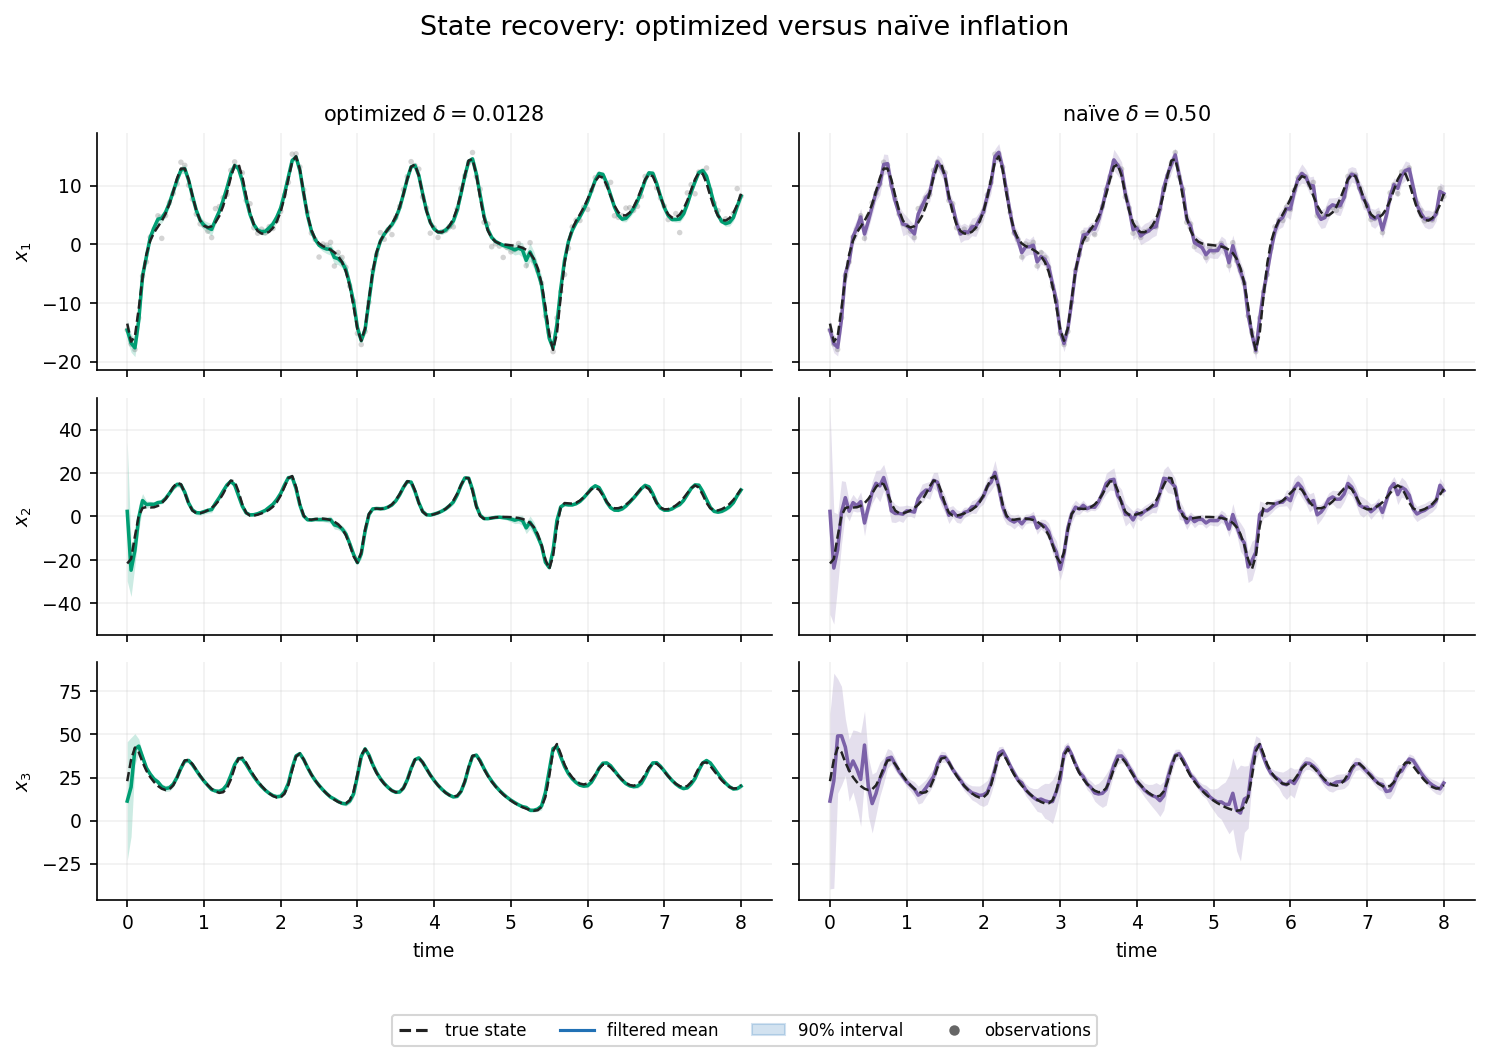

In [21]:
truth_np = np.asarray(true_states)
times_np = np.asarray(obs_times)
observations_np = np.asarray(obs_values[:, 0])
recovery_colors = ("#009E73", "#7B61A8")

metric_lines = [
    "| Inflation choice | Overall RMSE | State RMSE $(x_1,x_2,x_3)$ | 90% coverage |",
    "|---|---:|:---:|---:|",
]
for label, recovery in recovery_results.items():
    error = recovery["mean"] - truth_np
    rmse_by_state = np.sqrt(np.mean(error**2, axis=0))
    overall_rmse = np.sqrt(np.mean(error**2))
    coverage = np.mean(
        (truth_np >= recovery["lo90"]) & (truth_np <= recovery["hi90"])
    )
    rmse_text = ", ".join(f"{value:.3f}" for value in rmse_by_state)
    metric_lines.append(
        f"| {label} | {overall_rmse:.3f} | {rmse_text} | {coverage:.3f} |"
    )

display(Markdown("\n".join(metric_lines)))

fig, axes = plt.subplots(
    STATE_DIM,
    len(recovery_results),
    figsize=(10.0, 7.0),
    sharex=True,
    sharey="row",
)
for column, ((label, recovery), color) in enumerate(
    zip(recovery_results.items(), recovery_colors, strict=True)
):
    for state_index in range(STATE_DIM):
        ax = axes[state_index, column]
        ax.fill_between(
            times_np,
            recovery["lo90"][:, state_index],
            recovery["hi90"][:, state_index],
            color=color,
            alpha=0.20,
            linewidth=0,
        )
        ax.plot(
            times_np,
            recovery["mean"][:, state_index],
            color=color,
            linewidth=1.7,
            label="filtered mean",
        )
        ax.plot(
            times_np,
            truth_np[:, state_index],
            color=TRUTH_COLOR,
            linestyle="--",
            linewidth=1.2,
            label="true state",
        )
        if state_index == 0:
            ax.scatter(
                times_np,
                observations_np,
                s=7,
                color=OBS_COLOR,
                alpha=0.28,
                edgecolors="none",
                label="observations",
            )
            ax.set_title(label)
        if column == 0:
            ax.set_ylabel(fr"$x_{state_index + 1}$")
        if state_index == STATE_DIM - 1:
            ax.set_xlabel("time")
        ax.grid(alpha=0.18)

legend_handles = [
    mpl.lines.Line2D([], [], color=TRUTH_COLOR, linestyle="--", label="true state"),
    mpl.lines.Line2D([], [], color=PROFILE_COLOR, label="filtered mean"),
    mpl.patches.Patch(color=PROFILE_COLOR, alpha=0.20, label="90% interval"),
    mpl.lines.Line2D(
        [], [], color=OBS_COLOR, marker="o", linestyle="none", markersize=4,
        label="observations",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
)
fig.suptitle("State recovery: optimized versus naïve inflation", fontsize=13)
fig.tight_layout(rect=(0.0, 0.06, 1.0, 0.96))
save_figure(fig, "optimized_vs_naive_state_recovery")
plt.show()
